**Introduction:**
Using a social media addiction vs productivity data set, we will develop a full data science analysis, ranging from data treatment to machine learning, passing by a exploratory data analysis with correlation and segmented analysis. 

**Importing libraries and data, cleaning data:** 

In [1]:
import numpy as np
import duckdb as db
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
import scipy.stats as stats
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
csv = 'social_media_productivity_6000.csv'
df = pd.read_csv(csv)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   object 
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), object(1)
memory usage: 422.0+ KB


In [3]:
df.head()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score
0,21.0,5.95,2.81,2.61,6.99,283.0,100.00,Medium,28.49
1,34.0,3.82,2.33,0.28,7.47,266.0,93.65,Medium,18.54
2,29.0,3.57,1.64,5.21,6.34,137.0,100.00,Low,68.52
3,25.0,10.27,4.37,4.28,4.49,247.0,94.71,Medium,27.82
4,22.0,2.42,1.60,3.67,6.34,28.0,100.00,Low,51.09


In [4]:
print("\n Veryifing missing values:\n")
print(df.isnull().sum())


 Veryifing missing values:

age                      120
daily_screen_time        120
social_media_hours       120
study_hours              120
sleep_hours              120
notifications_per_day    120
focus_score              120
addiction_level          120
productivity_score       120
dtype: int64


In [5]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


Roughly 13% of our data has missing values. We will drop this data, and use the remaining data for our analysis. 

In [7]:
dfclean = df.dropna().copy()
print("\n Verifying missing values:\n")
print(dfclean.isnull().sum())


 Verifying missing values:

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


In [8]:
dfclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 5998
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    4999 non-null   float64
 1   daily_screen_time      4999 non-null   float64
 2   social_media_hours     4999 non-null   float64
 3   study_hours            4999 non-null   float64
 4   sleep_hours            4999 non-null   float64
 5   notifications_per_day  4999 non-null   float64
 6   focus_score            4999 non-null   float64
 7   addiction_level        4999 non-null   object 
 8   productivity_score     4999 non-null   float64
dtypes: float64(8), object(1)
memory usage: 390.5+ KB


**Exploratory Data Analysis (EDA):**
We will begin our EDA by looking at two histograms of what we imagine to be some of the most important data on this dataset: productivity score and daily screen time. The plan is to identify outliers and start an action plan. 

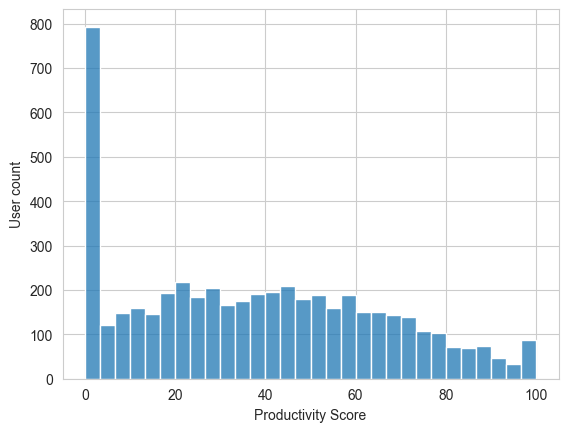

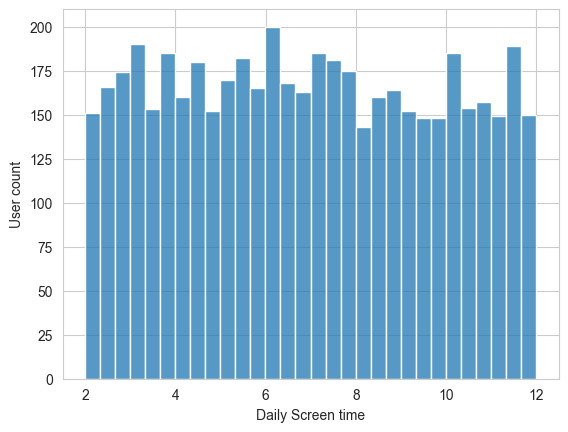

In [34]:
#Visualizing productivity data

with sns.axes_style("whitegrid"):
    sns.histplot(dfclean, x='productivity_score', bins=30)
    plt.xlabel('Productivity Score')
    plt.ylabel('User count')
    plt.show()
    
    sns.histplot(dfclean, x='daily_screen_time', bins=30)
    plt.xlabel('Daily Screen time')
    plt.ylabel('User count')
    plt.show()

Daily screen time data has no outliers, with values distributed without an apparent formula. But there is a noticeable outlier on low productivity scores. Let's see if they are invalid users or users with real data but no productivity score. 

In [32]:
df_zeros = dfclean[dfclean['productivity_score'] == 0]
display(df_zeros.sample(10))

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,addiction_level,productivity_score,screentime_group
4593,33.0,10.04,3.25,0.51,5.75,29.0,99.02,Medium,0.0,Very high screen time (+9.5h)
3522,37.0,10.10,4.43,1.01,6.18,248.0,86.95,Medium,0.0,Very high screen time (+9.5h)
2998,38.0,7.78,5.06,0.75,5.09,65.0,88.58,High,0.0,High screen time (7-9.5h)
34,29.0,10.44,8.88,1.57,7.48,261.0,76.18,High,0.0,Very high screen time (+9.5h)
3034,34.0,4.63,3.79,0.11,8.46,283.0,92.96,Medium,0.0,Normal screen time (4.5-7h)
1771,24.0,10.19,8.08,4.18,6.26,77.0,100.00,High,0.0,Very high screen time (+9.5h)
3125,15.0,7.80,6.74,0.48,5.64,220.0,73.54,High,0.0,High screen time (7-9.5h)
2316,30.0,9.88,7.13,0.53,4.24,292.0,61.09,High,0.0,Very high screen time (+9.5h)
352,33.0,10.98,9.65,2.60,4.27,280.0,61.74,High,0.0,Very high screen time (+9.5h)
3113,23.0,10.35,8.82,2.99,6.51,179.0,70.10,High,0.0,Very high screen time (+9.5h)


Luckily, it is the second option. The data is real, but the users have no productivity score. This will have consequences such as making our linear regressions worse and **lowering the average productivity score of the population**, but we will keep this data.

Now, let's calculate a correlation matrix between the data in order to formulate hypotheses and study the relationship between the data. 

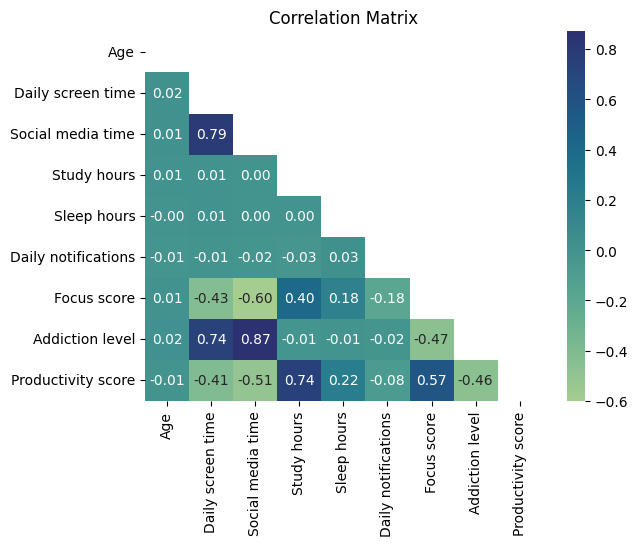

In [9]:
#Calculating the correlation matrix to formulate hypotheses.

#mapping addiction level to number values.
mapping = {'High': 2, 'Medium': 1, 'Low': 0}

dfnumeric = dfclean.copy()
dfnumeric['addiction_level'] = df['addiction_level'].map(mapping)
dfplot = dfnumeric.copy()

dfplot.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Addiction level', 'Productivity score'] 

corr = pd.DataFrame(dfplot.corr())
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot = True, fmt = ".2f", cmap="crest")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix provides us with a lot of data. Some of this data, although expected, is very important: daily screen time has a **linear negative correlation** with productivity and focus, with social media time having an **even bigger negative correlation**. This difference can be explained by the productive use of the screen (for work or study). Study hours have a **great positive correlation** with productivity and a lower but **still noticeable positive correlation** with focus. Sleep hours also have a positive correlation with both productivity and focus, albeit a smaller one. 

The most striking correlation is between the social media time and the focus and productivity. Besides being the biggest negative correlation, one aspect is worth mentioning: the productivity score has a smaller negative correlation than focus. Users with higher addiction levels not only appear to have more trouble being productive but also have to **exert significantly more focus** to achieve it.

Part of the data is unexpected: even though daily notifications have a **negative impact** on focus, it doesn't appear to impact productivity. Screen and social media time do not correlate with study and sleep hours, even though one would expect a negative correlation. Age also does not appear to have an impact on addiction level.

Let's confirm this absence of impact using a correlation significance test. Next, we will do a hypothesis test to confirm if the correlation between productivity score and addiction level is statistically significant. 

In [10]:
# Confirming if age has an impact on addiction level. 
df_test = dfclean[['age', 'addiction_level']].copy()

# (Spearman as the distribution is not normal)
correlation, p_value = stats.spearmanr(df_test['age'], df_test['addiction_level'])

print("--- Correlation Significance Test ---")
print(f"Correlation Coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value:.4e}\n")

# 3. Define thresholds for both Statistical and Practical significance
alpha = 0.05                  # Statistical threshold (5%)
practical_threshold = 0.10    # Practical threshold (e.g., |r| < 0.1 is considered negligible)

print("--- Final Conclusion ---")

# Step 1: Check for Statistical Significance (Is it random chance?)
if p_value < alpha:
    print("1. Statistical Check: PASS (We reject H0)")
    print("   -> The correlation is statistically significant. It is likely not zero.")
    
    # Step 2: Check for Practical Significance (Is it actually useful?)
    if abs(correlation) < practical_threshold:
        print("\n2. Practical Check: FAIL")
        print("   -> The correlation is statistically real, but practically useless.")
        print("   -> The coefficient is too close to zero to be meaningful in the real world.")
    elif correlation > 0:
        print("\n2. Practical Check: PASS")
        print("   -> There is a meaningful POSITIVE relationship between Age and Addiction Level.")
    else:
        print("\n2. Practical Check: PASS")
        print("   -> There is a meaningful NEGATIVE relationship between Age and Addiction Level.")

# If it fails the statistical check, we don't even need to look at practical significance
else:
    print("1. Statistical Check: FAIL (We fail to reject H0)")
    print("   -> There is no statistical evidence of a correlation.")
    print("   -> Any observed relationship in the sample might just be due to random chance.")

--- Correlation Significance Test ---
Correlation Coefficient (r): -0.0292
P-value: 3.9171e-02

--- Final Conclusion ---
1. Statistical Check: PASS (We reject H0)
   -> The correlation is statistically significant. It is likely not zero.

2. Practical Check: FAIL
   -> The correlation is statistically real, but practically useless.
   -> The coefficient is too close to zero to be meaningful in the real world.


In [11]:
# Testing if the correlation between addiction level and productivity is statistically relevant. 

# 1. Separate the data into the two groups we want to compare
prod_high = dfclean[dfclean['addiction_level'] == 'High']['productivity_score'].dropna()
prod_low = dfclean[dfclean['addiction_level'] == 'Low']['productivity_score'].dropna()

print(f"Size of High Addiction group: {len(prod_high)}")
print(f"Size of Low Addiction group: {len(prod_low)}\n")

# 2. Normality Test (Shapiro-Wilk)
# H0: The data follows a normal distribution
_, p_norm_high = stats.shapiro(prod_high)
_, p_norm_low = stats.shapiro(prod_low)

print("--- Assumption 1: Normality ---")
print(f"P-value (High): {p_norm_high:.4f} | P-value (Low): {p_norm_low:.4f}")

# 3. Homogeneity of Variances Test (Levene)
# H0: The variances of the groups are equal
_, p_var = stats.levene(prod_high, prod_low)

print("\n--- Assumption 2: Equal Variances ---")
print(f"Levene P-value: {p_var:.4f}\n")

# 4. Decision Tree for the Correct Test
alpha = 0.05 # Standard significance level of 5%

print("--- Hypothesis Test Result ---")

if p_norm_high > alpha and p_norm_low > alpha:
    # Both are normal
    if p_var > alpha:
        # Equal variances -> Independent Student's T-Test (Standard)
        print("Applying: Independent Student's T-Test")
        stat, p_final = stats.ttest_ind(prod_high, prod_low, equal_var=True)
    else:
        # Unequal variances -> Welch's T-Test
        print("Applying: Welch's T-Test")
        stat, p_final = stats.ttest_ind(prod_high, prod_low, equal_var=False)
else:
    # At least one is not normal -> Non-Parametric Test (Mann-Whitney U)
    print("Applying: Mann-Whitney U Test (Non-parametric)")
    stat, p_final = stats.mannwhitneyu(prod_high, prod_low, alternative='two-sided')

print(f"Test Statistic: {stat:.4f}")
print(f"Final P-Value: {p_final:.4e}")

# 5. Conclusion
if p_final < alpha:
    print("\nConclusion: We reject the Null Hypothesis (H0).")
    print("There is a statistically significant difference in productivity between the high and low addiction groups.")
else:
    print("\nConclusion: We fail to reject the Null Hypothesis (H0).")
    print("There is not enough statistical evidence to state that productivity differs between the groups.")

Size of High Addiction group: 1585
Size of Low Addiction group: 809

--- Assumption 1: Normality ---
P-value (High): 0.0000 | P-value (Low): 0.0000

--- Assumption 2: Equal Variances ---
Levene P-value: 0.0000

--- Hypothesis Test Result ---
Applying: Mann-Whitney U Test (Non-parametric)
Test Statistic: 179502.0000
Final P-Value: 4.0018e-185

Conclusion: We reject the Null Hypothesis (H0).
There is a statistically significant difference in productivity between the high and low addiction groups.


**Segmented Analysis** 

We saw in the correlation matrix that daily screen time had a negative correlation with productivity and focus. Let's dip our toes in a screen time segmented analysis, to see how much this screen time affects both scores.

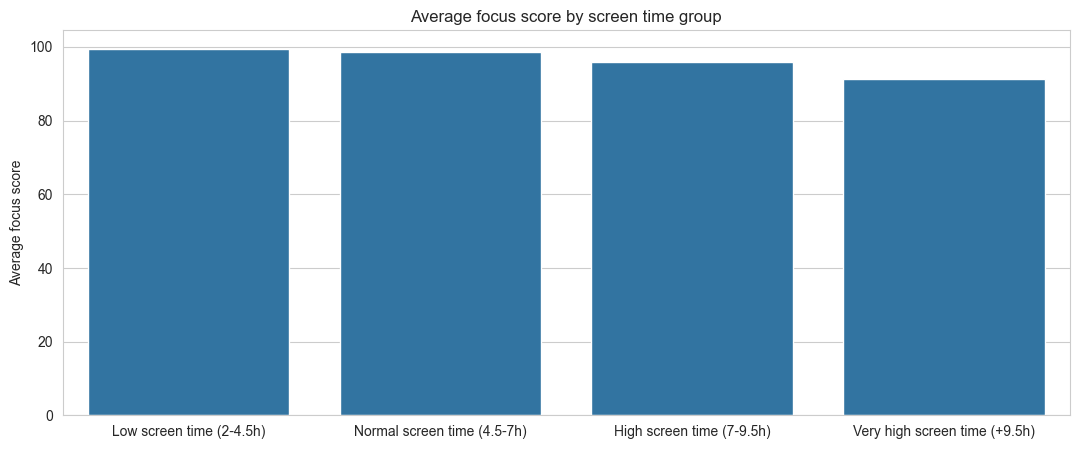

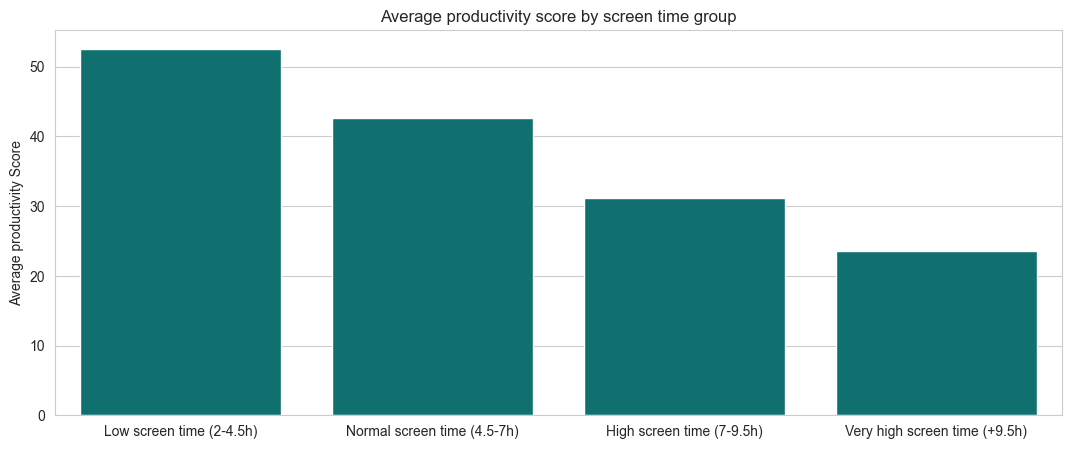

In [21]:
# Segmented analysis by screen time. Groups defined by quartiles.
screen_time_label = ['Low screen time (2-4.5h)', 'Normal screen time (4.5-7h)', 'High screen time (7-9.5h)', 'Very high screen time (+9.5h)']
dfclean['screentime_group'] = pd.cut(dfclean['daily_screen_time'], bins=[2, 4.5, 7, 9.5, 12], labels=screen_time_label, right=False)

focus_prod = db.query('SELECT screentime_group, AVG(focus_score), AVG(productivity_score) FROM dfclean GROUP BY screentime_group ORDER BY screentime_group').df()

with sns.axes_style("whitegrid"): 
    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod, x='screentime_group', y ='avg(focus_score)')
    plt.title('Average focus score by screen time group')
    plt.xlabel('')
    plt.ylabel('Average focus score')
    plt.show()

    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod, x='screentime_group', y ='avg(productivity_score)', color='teal')
    plt.title('Average productivity score by screen time group')
    plt.xlabel('')
    plt.ylabel('Average productivity Score')
    plt.show()



Screen time has a small influence on focus. Users with low screen time have a near-perfect average focus score of **99.51**, while very high screen time users have approximately a 8% decrease, with **91.25 average focus score**.

The influence on productivity, however, is astounding. Low screen time users have a **average productivity score of 52.61**. Normal screen time users have a 19% decrease **(42.60 productivity score)**, high screen time users have a 40% decrease, with a score of **31.20** and very high screen time users have a total decrease of 55% in productivity score, which amounts to a value of only **23.60**.

Let's use this segmented analysis to see if the correlation between study/sleep time and screen time appears when looking at the two higher time groups.

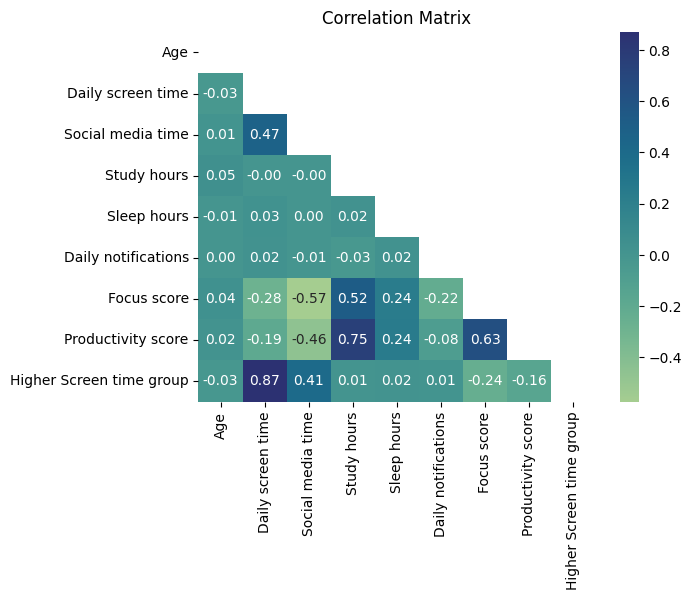

In [13]:
screen_time_numlabel = {'Low screen time (2-4.5h)':0, 'Normal screen time (4.5-7h)':1, 'High screen time (7-9.5h)':2, 'Very high screen time (+9.5h)':3}

higher_screentime = dfclean.copy()
higher_screentime = higher_screentime.drop(columns=['addiction_level'])
higher_screentime['screentime_group'] = higher_screentime['screentime_group'].map(screen_time_numlabel).astype(int)
higher_screentime = higher_screentime[higher_screentime['screentime_group'] >= 2]
higher_screentime.columns = ['Age', 'Daily screen time', 'Social media time', 
    'Study hours', 'Sleep hours', 'Daily notifications', 
    'Focus score', 'Productivity score', 'Higher Screen time group'] 

corr = pd.DataFrame(higher_screentime.corr())
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot = True, fmt = ".2f", cmap="crest")
plt.title("Correlation Matrix")
plt.show()


Still no correlation between screen time and sleep or study hours. One can deduce that even for higher screen time groups, the screen time is stealing time from other areas not mapped, like family/leisure time, instead of sleep and study time. 

Next, let's see if users with higher addiction levels or more screen time receive more notifications per day.

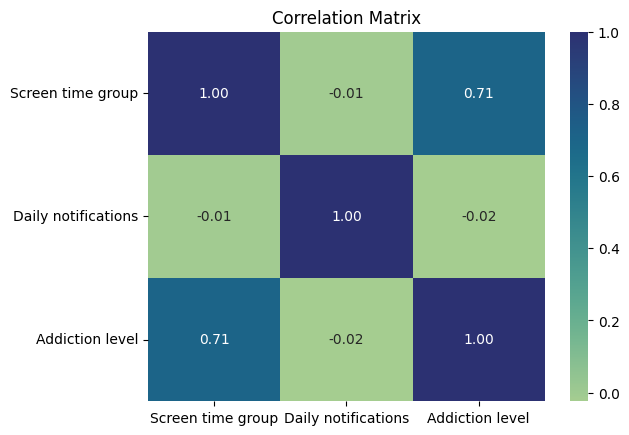

In [14]:
#Correlation between screen time group, addiction level, and amount of daily notifications.
dfplot['Screen time group'] = pd.cut(dfplot['Daily screen time'], bins=[2, 4.5, 7, 9.5, 12], labels=screen_time_label, right=False)
corr_test = dfplot[['Screen time group', 'Daily notifications', 'Addiction level']].copy()
corr_test['Screen time group'] = corr_test['Screen time group'].map(screen_time_numlabel).astype(int)

corr_testdf = pd.DataFrame(corr_test.corr())

sns.heatmap(corr_testdf, annot = True, fmt = ".2f", cmap="crest")
plt.title("Correlation Matrix")
plt.show()


There is no correlation found between the amount of daily notifications and the screen time group or addiction level, meaning that for this data set, restricting access to notifications may not help a user with their addiction.

Going back to the first correlation matrix, there is a big negative correlation between daily screen time and productivity/focus score. But an even bigger one was found between social media time and those score metrics. So, let's do another segmented analysis and see if a different pattern emerges.

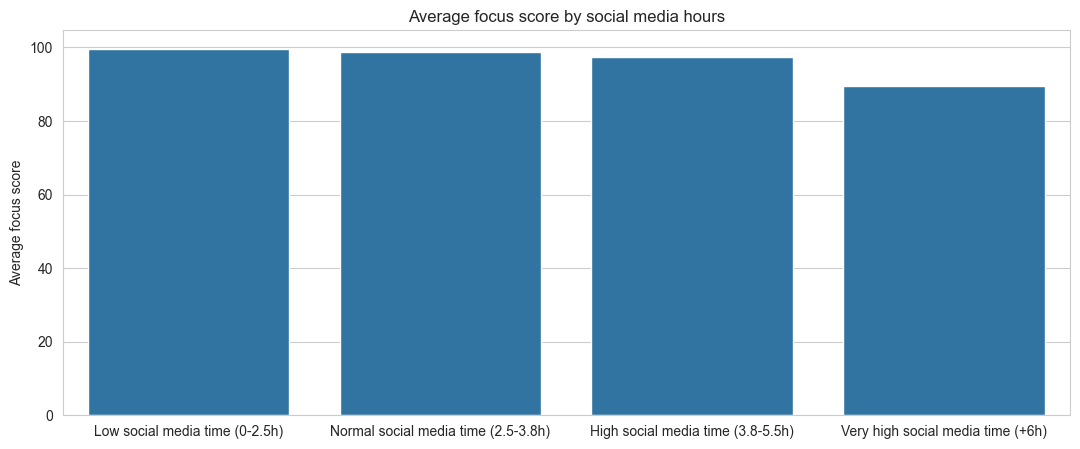

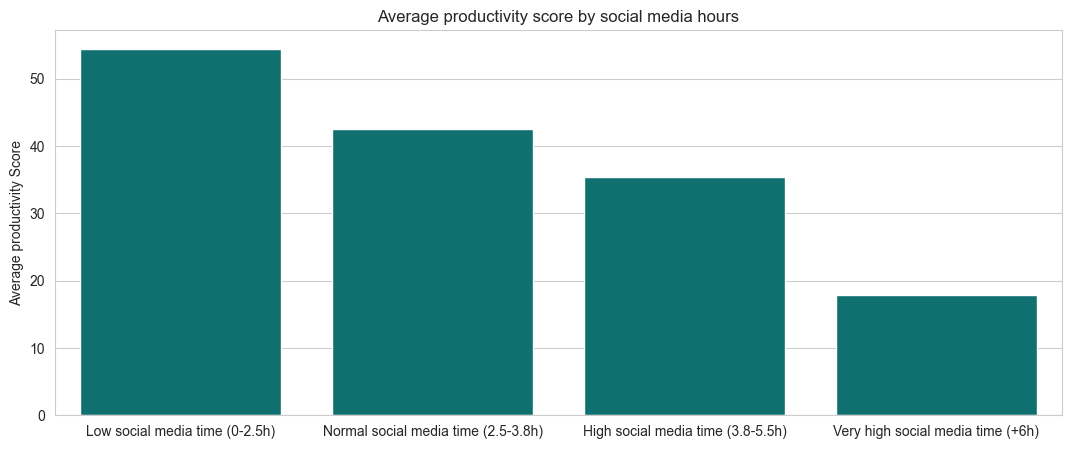

In [41]:
# Segmented analysis by social media time. Groups defined by quartiles.
social_media_label = ['Low social media time (0-2.5h)', 'Normal social media time (2.5-3.8h)', 'High social media time (3.8-5.5h)', 'Very high social media time (+6h)']
dfclean['social_media_group'] = pd.cut(dfclean['social_media_hours'], bins=[0, 2.5, 3.8, 5.5, 11], labels=social_media_label, right=False)

focus_prod2 = db.query('SELECT social_media_group, AVG(focus_score), AVG(productivity_score) FROM dfclean GROUP BY social_media_group ORDER BY social_media_group').df()

with sns.axes_style("whitegrid"): 
    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod2, x='social_media_group', y ='avg(focus_score)')
    plt.title('Average focus score by social media hours')
    plt.xlabel('')
    plt.ylabel('Average focus score')
    plt.show()

    plt.figure(figsize = (13, 5))
    sns.barplot(data=focus_prod2, x='social_media_group', y ='avg(productivity_score)', color='teal')
    plt.title('Average productivity score by social media hours')
    plt.xlabel('')
    plt.ylabel('Average productivity Score')
    plt.show()



Social media has a relevant impact on both focus and productivity scores. When comparing the low social media time group with the very high one, the **focus score decrease in more than 10%**, with average focus score going below **90**. But the biggest impact of all appear when analyzing productivity. Moving from one group to another has always a big decrease, with a 22% decrease when going from low **(54.47)** use to normal use **(42.59)**, a 35% decrease when going from low to high **(35.34)** use, and **a 67% decrease** between the two extrema, with very high social media users having only **17.85 average productivity score**. 

This data confirms our previous statement: screen time has a very negative impact, but this impact is still smaller than the one caused by specific social media time, as screen time also considers productive screen time, such as work and study.

**Predictive Analysis with Machine Learning:**

It is time to utilize this data in machine learning models, with two different goals: the first one is learning the most important elements in calculating productivity score, which can lead to a more specific plan of action towards maximizing one's productivity. The second goal is to develop a model capable of predicting addiction level of a user using the available data. 

For the first case, we will use linear regression, random forest and XGBoost. For the second, we will use random forest and XGBoost. In both cases, we will develop the model using a 5-fold cross validation process, in order to avoid overfitting. 

In [15]:
#Using Machine Learning to evaluate the most important data in calculating productivity. 

# Define Features (X) and Target (y)
features = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day', 'social_media_hours']
target = 'productivity_score'

X = dfclean[features]
y = dfclean[target]


# Algorithms like Linear Regression perform better when features are on the same scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize the Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Validate each model with 5-Fold CV
print("--- 5-Fold Cross-Validation Results ---\n")

results = []
for name, model in models.items():
    # neg_root_mean_squared_error returns negative values, so we negate
    rmse_scores = -cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error')
    r2_scores   =  cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'RMSE mean': rmse_scores.mean(),
        'RMSE std':  rmse_scores.std(),
        'R2 mean':   r2_scores.mean(),
        'R2 std':    r2_scores.std(),
    })
    
    print(f"[{name}]")
    print(f"RMSE: {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
    print(f"R²:   {r2_scores.mean():.4f}  ± {r2_scores.std():.4f}\n")

results_df = pd.DataFrame(results).sort_values(by='RMSE mean', ascending=True)
results_df

--- 5-Fold Cross-Validation Results ---

[Linear Regression]
RMSE: 10.3971 ± 0.1818
R²:   0.8582  ± 0.0057

[Random Forest]
RMSE: 9.8045 ± 0.0915
R²:   0.8739  ± 0.0019

[XGBoost]
RMSE: 9.7106 ± 0.0952
R²:   0.8764  ± 0.0014



,Model,RMSE mean,RMSE std,R2 mean,R2 std
2,XGBoost,9.710644,0.095239,0.876359,0.001391
1,Random Forest,9.804480,0.091475,0.873950,0.001919
0,Linear Regression,10.397143,0.181840,0.858184,0.005658


The 3 Machine Learning models utilized worked well, with a high R² (>0.85) and a low RMSE (<11). As expected, the worst model in the tree was linear regression, given that the productivity score data, as we previously verified in the histograms, is highly nonlinear. The best model was XGBoost, with a R² of 0.876, which means that **this model explains almost 88% of the variation in productivity using only the 5 features given by the data** (sleep and study hours, daily screen time, social media time and the amount of notifications per day). XGBoost also featured an **average error of 10% (9.71)** when evaluating the productivity score of a user. 

Let's use XGBoost to evaluate the most important features for the productivity score. 

In [16]:
best_model = models["XGBoost"]

best_model.fit(X_scaled, y)

importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (What drives productivity?) ---")
feature_importance_df


--- Feature Importance (What drives productivity?) ---


,Feature,Importance
1,study_hours,0.581060
4,social_media_hours,0.329318
0,sleep_hours,0.058348
3,notifications_per_day,0.019696
2,daily_screen_time,0.011578


The model tells us that the biggest factor driving productivity is the amount of study hours, followed by the amount of time spent on social media. Given the correlation matrix analysed previously, we can say that the first factor has a positive importance **(more hours studied, more productivity)**, while the second one has a negative importance **(more time spent on social media, less productivity)**. This conclusion agrees with the segmented analysis done previously.

--- 5-Fold Cross-Validation Results ---

[Random Forest]
CV Accuracy:  1.0000 ± 0.0000
CV Precision: 1.0000
CV Recall:    1.0000

[XGBoost]
CV Accuracy:  0.9960 ± 0.0015
CV Precision: 0.9960
CV Recall:    0.9960

--- Final Evaluation on Unseen Test Data ---

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       165
         1.0       1.00      1.00      1.00       554
         2.0       1.00      1.00      1.00       281

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



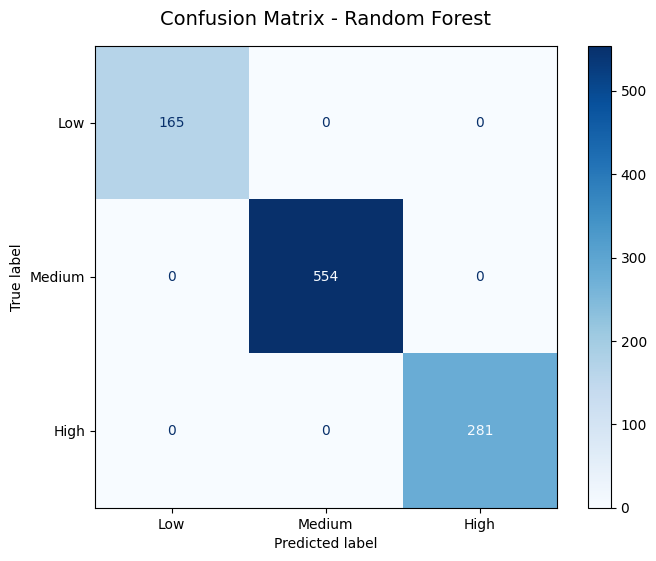

In [17]:
#Using Machine Learning to predict addiction level based on user behavior.
featurespred = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day', 'social_media_hours']
targetpred = 'addiction_level'

X2 = dfnumeric[featurespred]
y2 = dfnumeric[targetpred]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

modelspred = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

print("--- 5-Fold Cross-Validation Results ---\n")

results = []

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted']

for name, model in modelspred.items():
    cv_scores = cross_validate(model, X_train_scaled2, y_train2, cv=5, scoring=scoring_metrics)
    
    mean_acc = cv_scores['test_accuracy'].mean()
    mean_prec = cv_scores['test_precision_weighted'].mean()
    mean_rec = cv_scores['test_recall_weighted'].mean()
    
    results.append({
        'Model': name, 
        'CV Accuracy': mean_acc, 
        'CV Precision': mean_prec, 
        'CV Recall': mean_rec
    })
    
    print(f"[{name}]")
    print(f"CV Accuracy:  {mean_acc:.4f} ± {cv_scores['test_accuracy'].std():.4f}")
    print(f"CV Precision: {mean_prec:.4f}")
    print(f"CV Recall:    {mean_rec:.4f}\n")
    
best_result = max(results, key=lambda x: x['CV Accuracy'])
best_modelpred = modelspred[best_result['Model']]

best_modelpred.fit(X_train_scaled2, y_train2)

predictions_final = best_modelpred.predict(X_test_scaled2)

print("--- Final Evaluation on Unseen Test Data ---\n")
print(classification_report(y_test2, predictions_final))

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    best_modelpred, 
    X_test_scaled2, 
    y_test2,
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f"Confusion Matrix - {best_result['Model']}", fontsize=14, pad=15)
plt.show()

Both models had a very good (and unusual) result, with Random Forest getting perfect results in precision, recall and accuracy. This probably means that the dataset utilized has a Target Leakage. The first and most likely hypotesis is that addiction level is calculated directly by the daily social media hours. Let's do both predictive models again, but without social media hours on the feature list.

--- 5-Fold Cross-Validation Results ---

[Random Forest]
CV Accuracy:  0.6717 ± 0.0175
CV Precision: 0.6723
CV Recall:    0.6717

[XGBoost]
CV Accuracy:  0.6784 ± 0.0207
CV Precision: 0.6797
CV Recall:    0.6784

--- Final Evaluation on Unseen Test Data ---

              precision    recall  f1-score   support

         0.0       0.67      0.60      0.63       165
         1.0       0.74      0.68      0.71       554
         2.0       0.62      0.76      0.69       281

    accuracy                           0.69      1000
   macro avg       0.68      0.68      0.68      1000
weighted avg       0.69      0.69      0.69      1000



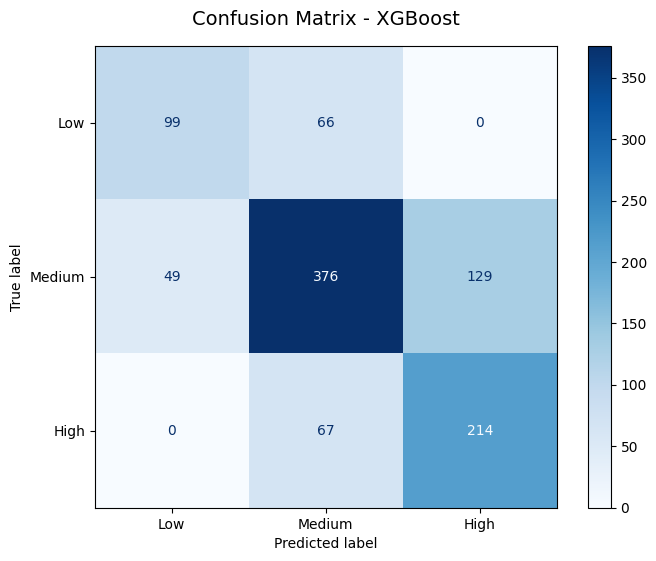

In [18]:
#Using Machine Learning to predict addiction level based on user behavior without social media hours.
featurespred = ['sleep_hours', 'study_hours', 'daily_screen_time', 'notifications_per_day']
targetpred = 'addiction_level'

X2 = dfnumeric[featurespred]
y2 = dfnumeric[targetpred]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train2)
X_test_scaled2 = scaler.transform(X_test2)

modelspred = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

print("--- 5-Fold Cross-Validation Results ---\n")

results = []

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted']

for name, model in modelspred.items():
    cv_scores = cross_validate(model, X_train_scaled2, y_train2, cv=5, scoring=scoring_metrics)
    
    mean_acc = cv_scores['test_accuracy'].mean()
    mean_prec = cv_scores['test_precision_weighted'].mean()
    mean_rec = cv_scores['test_recall_weighted'].mean()
    
    results.append({
        'Model': name, 
        'CV Accuracy': mean_acc, 
        'CV Precision': mean_prec, 
        'CV Recall': mean_rec
    })
    
    print(f"[{name}]")
    print(f"CV Accuracy:  {mean_acc:.4f} ± {cv_scores['test_accuracy'].std():.4f}")
    print(f"CV Precision: {mean_prec:.4f}")
    print(f"CV Recall:    {mean_rec:.4f}\n")
    
best_result = max(results, key=lambda x: x['CV Accuracy'])
best_modelpred = modelspred[best_result['Model']]

best_modelpred.fit(X_train_scaled2, y_train2)

predictions_final = best_modelpred.predict(X_test_scaled2)

print("--- Final Evaluation on Unseen Test Data ---\n")
print(classification_report(y_test2, predictions_final))

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_estimator(
    best_modelpred, 
    X_test_scaled2, 
    y_test2,
    display_labels=['Low', 'Medium', 'High'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title(f"Confusion Matrix - {best_result['Model']}", fontsize=14, pad=15)
plt.show()

As expected, our models are now worse, but more realistic. **Random Forest**  performed slightly better than XGBoost, but both models displayed similar behavior: they are better at analyzing users with medium addiction levels, as its f1-score (the harmonic mean between precision and recall), responsible for evaluating the model, is higher. This better result is given by the fact that the support (amount of users in this category in testing data) for medium level is 554, while for low it is only 165. 

Visualizing the Confusion Matrix for the Random Forest model also gives us one critical insight. The model did not commit major errors, such as predicting a high label to a low labelled user (and vice versa). There are two reasons behind this behavior: the first one is the logical gradient formed by the data, making it easier for the algorithms to distinguish extrema, while the second one is the bigger support for medium labels, as the model is statistically skewed towards them.

**Conclusions:**

Our analysis showed, without doubt, that social media addiction is responsible for a decrease in productivity. This behavior appeared both in a segmented analysis by daily screen time and daily social media time, and in a machine learning analysis that measured feature importance for productivity. A different machine learning pipeline allowed us to predict addiction level for users, complete with learning that our data had a target leakage caused by the calculation of addiction level directly from the social media time data. With target leakage fixed, our best model had good results, with no major errors caused by it, and a recall of over 60% for all 3 possible labels.   

We also learned that for this data, high screen time does not take away from sleep and study time, an unexpected result that opens possibilities for new data acquisition and analysis: from where does high screen time take away time? Leisure time? Family time?
